# Task 3 — Improvement, Ablation, 5-Fold CV, Significance, Final Test



In [1]:
# Cell 1 — Imports and Configuration

import time, json, warnings, re
import subprocess, sys
warnings.filterwarnings("ignore")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch-geometric", "xgboost", "lightgbm"],
    check=False
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
)
from scipy.stats import wilcoxon

import xgboost as xgb
import lightgbm as lgb

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGLoader
from torch_geometric.nn import (
    GCNConv, GATConv, SAGEConv,
    global_mean_pool, global_max_pool,
)

FEATURE_PATH = Path("/kaggle/input/datasets/tahminaahmed151/putemg-window-feature-dataset-parquet/putemg_window_feature_dataset.parquet")
SPLIT_PATH = Path("/kaggle/input/datasets/tahminaahmed151/task2-baseline-result/split_info.json")
BASELINE_RESULTS_PATH = Path("/kaggle/input/datasets/tahminaahmed151/task2-baseline-result/baseline_results.csv")
TASK2_GNN_RESULTS_PATH = Path("/kaggle/input/datasets/tahminaahmed151/task2-proposed-model/gnn_val_results.json")

for required_path in [
    FEATURE_PATH,
    SPLIT_PATH,
    BASELINE_RESULTS_PATH,
    TASK2_GNN_RESULTS_PATH,
]:
    assert required_path.exists(), f"Required input not found: {required_path}"

OUTPUT_FOLDER = Path("/kaggle/working/task3_results")
MODELS_FOLDER = Path("/kaggle/working/models")
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
MODELS_FOLDER.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

GESTURE_NAMES = {
    0: "Idle",        1: "Fist",
    2: "Flexion",     3: "Extension",
    6: "Pinch-Index", 7: "Pinch-Middle",
    8: "Pinch-Ring",  9: "Pinch-Small",
}

N_CHANNELS = 24
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print("Setup complete.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.5 MB/s eta 0:00:00
Device: cuda
Setup complete.


## Cell 2 — Load Task 2 artifacts and reconstruct the exact subject splits


In [2]:
feature_df = pd.read_parquet(FEATURE_PATH)
print(f"Dataset loaded: {feature_df.shape}")

required_cols = {"subject_id", "label"}
assert required_cols.issubset(feature_df.columns), (
    f"Dataset is missing required columns: {sorted(required_cols - set(feature_df.columns))}"
)

with open(SPLIT_PATH, "r") as f:
    split_info = json.load(f)

required_split_keys = {
    "train_subjects",
    "val_subjects",
    "test_subjects",
    "feat_cols",
    "label_classes",
}
missing_split_keys = required_split_keys - set(split_info)
assert not missing_split_keys, (
    f"split_info.json is missing required keys: {sorted(missing_split_keys)}"
)

train_subjects = [int(s) for s in split_info["train_subjects"]]
val_subjects   = [int(s) for s in split_info["val_subjects"]]
test_subjects  = [int(s) for s in split_info["test_subjects"]]
dev_subjects   = sorted(train_subjects + val_subjects)

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)
assert set(dev_subjects).isdisjoint(test_subjects)

all_dataset_subjects = set(int(s) for s in feature_df["subject_id"].unique())
assert set(dev_subjects).union(test_subjects) == all_dataset_subjects, (
    "Saved Task-2 subjects do not exactly cover the current feature dataset."
)

train_df = feature_df[feature_df["subject_id"].isin(train_subjects)].copy().reset_index(drop=True)
val_df   = feature_df[feature_df["subject_id"].isin(val_subjects)].copy().reset_index(drop=True)
dev_df   = feature_df[feature_df["subject_id"].isin(dev_subjects)].copy().reset_index(drop=True)
test_df  = feature_df[feature_df["subject_id"].isin(test_subjects)].copy().reset_index(drop=True)

print(f"Task-2 train: {len(train_subjects)} subjects / {len(train_df):,} windows")
print(f"Task-2 val  : {len(val_subjects)} subjects / {len(val_df):,} windows")
print(f"Dev pool    : {len(dev_subjects)} subjects / {len(dev_df):,} windows")
print(f"Frozen test : {len(test_subjects)} subjects / {len(test_df):,} windows")

baseline_df = pd.read_csv(BASELINE_RESULTS_PATH)
required_baseline_cols = {"Model", "Macro-F1"}
missing_baseline_cols = required_baseline_cols - set(baseline_df.columns)
assert not missing_baseline_cols, (
    f"baseline_results.csv is missing required columns: {sorted(missing_baseline_cols)}"
)

baseline_df["Macro-F1"] = pd.to_numeric(baseline_df["Macro-F1"], errors="coerce")
assert baseline_df["Macro-F1"].notna().any(), (
    "baseline_results.csv contains no valid Macro-F1 values."
)

best_baseline_row = baseline_df.loc[baseline_df["Macro-F1"].idxmax()]
best_baseline_name = str(best_baseline_row["Model"]).strip()
best_baseline_f1 = float(best_baseline_row["Macro-F1"])

print(
    f"\nTask-2 best baseline: {best_baseline_name} | "
    f"validation Macro-F1={best_baseline_f1:.4f}"
)

with open(TASK2_GNN_RESULTS_PATH, "r") as f:
    task2_gnn_results = json.load(f)

assert "Macro-F1" in task2_gnn_results, (
    "gnn_val_results.json does not contain 'Macro-F1'."
)
first_gnn_f1 = float(task2_gnn_results["Macro-F1"])
print(f"Task-2 first Corr-GCN validation Macro-F1={first_gnn_f1:.4f}")

expected_labels = [int(c) for c in split_info["label_classes"]]
assert sorted(int(x) for x in feature_df["label"].unique()) == sorted(expected_labels)

print("\nCell 2 checks passed. Test subjects remain untouched.")


Dataset loaded: (619479, 196)
Task-2 train: 31 subjects / 435,797 windows
Task-2 val  : 6 subjects / 85,277 windows
Dev pool    : 37 subjects / 521,074 windows
Frozen test : 7 subjects / 98,405 windows

Task-2 best baseline: MLP (PyTorch) | validation Macro-F1=0.5346
Task-2 first Corr-GCN validation Macro-F1=0.3821

Cell 2 checks passed. Test subjects remain untouched.


## Cell 3 —  Five subject-grouped folds for final CV




In [3]:
N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

groups  = dev_df["subject_id"].to_numpy()
row_idx = np.arange(len(dev_df))
folds = []

for fold_id, (tr_idx, va_idx) in enumerate(gkf.split(row_idx, groups=groups), start=1):
    tr_subjects = sorted(int(s) for s in dev_df.iloc[tr_idx]["subject_id"].unique())
    va_subjects = sorted(int(s) for s in dev_df.iloc[va_idx]["subject_id"].unique())

    assert set(tr_subjects).isdisjoint(va_subjects), f"Fold {fold_id}: subject leakage"
    assert set(int(s) for s in dev_df.iloc[tr_idx]["subject_id"].unique()) == set(tr_subjects)
    assert set(int(s) for s in dev_df.iloc[va_idx]["subject_id"].unique()) == set(va_subjects)

    fold_train_labels = set(int(x) for x in dev_df.iloc[tr_idx]["label"].unique())
    fold_val_labels   = set(int(x) for x in dev_df.iloc[va_idx]["label"].unique())
    assert fold_train_labels == set(expected_labels), f"Fold {fold_id}: training fold misses a class"
    assert fold_val_labels == set(expected_labels), f"Fold {fold_id}: validation fold misses a class"

    folds.append((tr_idx, va_idx, tr_subjects, va_subjects))
    print(
        f"Fold {fold_id}: train {len(tr_subjects):2d} subjects / {len(tr_idx):>7,} windows | "
        f"val {len(va_subjects):2d} subjects / {len(va_idx):>6,} windows"
    )

all_val_subjects = sorted(s for _, _, _, va_subjects in folds for s in va_subjects)
assert all_val_subjects == dev_subjects, (
    "The 5 validation folds do not partition the 37 development subjects exactly once."
)
print("\n5-fold subject partition verified.")


Fold 1: train 30 subjects / 422,031 windows | val  7 subjects / 99,043 windows
Fold 2: train 29 subjects / 408,548 windows | val  8 subjects / 112,526 windows
Fold 3: train 29 subjects / 409,792 windows | val  8 subjects / 111,282 windows
Fold 4: train 30 subjects / 421,940 windows | val  7 subjects / 99,134 windows
Fold 5: train 30 subjects / 421,985 windows | val  7 subjects / 99,089 windows

5-fold subject partition verified.


## Cell 4 — Leakage-safe preprocessing, graph construction, and metric helpers




In [4]:
# Exact 168 feature columns saved by the Task-2 baseline notebook.
FEAT_PAT_7 = re.compile(r"EMG_\d+_(MAV|RMS|STD|VAR|WL|ZC|SSC)", re.I)
feat_cols_7 = [c for c in split_info["feat_cols"] if FEAT_PAT_7.fullmatch(c)]
assert len(feat_cols_7) == 168, f"Expected 168 Task-2 features, found {len(feat_cols_7)}"
assert all(c in feature_df.columns for c in feat_cols_7)

METRICS_7 = ["MAV", "RMS", "STD", "VAR", "WL", "ZC", "SSC"]
expected_order = [f"EMG_{ch}_{metric}" for metric in METRICS_7 for ch in range(1, N_CHANNELS + 1)]
assert [c.upper() for c in feat_cols_7] == [c.upper() for c in expected_order], (
    "Task-2 feature order is not metric-major; 24x7 reshape would be wrong."
)
N_METRICS = 7


def preprocess_split(fit_df, transform_df):
    """Fit every learned preprocessing step on fit_df only."""
    X_fit_raw = fit_df[feat_cols_7].to_numpy(dtype="float32")
    X_tr_raw  = transform_df[feat_cols_7].to_numpy(dtype="float32")

    assert np.isfinite(X_fit_raw).all() and np.isfinite(X_tr_raw).all(), "NaN/Inf in raw features"

    vt = VarianceThreshold(threshold=0.0)
    X_fit_vt = vt.fit_transform(X_fit_raw)
    X_tr_vt  = vt.transform(X_tr_raw)
    assert X_fit_vt.shape[1] == 168, (
        f"VarianceThreshold removed features ({X_fit_vt.shape[1]}/168); node reshape would break."
    )

    scaler = RobustScaler()
    X_fit = scaler.fit_transform(X_fit_vt).astype("float32")
    X_tr  = scaler.transform(X_tr_vt).astype("float32")
    assert np.isfinite(X_fit).all() and np.isfinite(X_tr).all(), "NaN/Inf after scaling"

    le = LabelEncoder()
    y_fit = le.fit_transform(fit_df["label"].to_numpy())
    y_tr  = le.transform(transform_df["label"].to_numpy())
    assert [int(c) for c in le.classes_] == expected_labels, "Unexpected label encoding"

    return {
        "X_fit": X_fit, "X_transform": X_tr,
        "y_fit": y_fit, "y_transform": y_tr,
        "vt": vt, "scaler": scaler, "le": le,
    }


def to_node_features(X):
    """(n,168) metric-major -> (n,24,7) electrode nodes x features."""
    assert X.shape[1] == N_CHANNELS * N_METRICS
    return X.reshape(-1, N_METRICS, N_CHANNELS).transpose(0, 2, 1)


def build_graph(X_train_nodes, graph_method="topk", top_k=4,
                edge_weight_mode="correlation"):
    """Build graph from TRAINING subjects only using MAV across windows."""
    assert graph_method in ("topk", "dense")
    assert edge_weight_mode in ("correlation", "binary")
    if graph_method == "topk":
        assert 1 <= int(top_k) < N_CHANNELS

    ch_mav = X_train_nodes[:, :, 0]
    corr = np.corrcoef(ch_mav.T)
    assert corr.shape == (N_CHANNELS, N_CHANNELS)
    assert np.isfinite(corr).all(), "Correlation matrix contains NaN/Inf"
    corr_abs = np.abs(corr).astype("float32")
    np.fill_diagonal(corr_abs, 0.0)

    if graph_method == "topk":
        adj = np.zeros((N_CHANNELS, N_CHANNELS), dtype="float32")
        for i in range(N_CHANNELS):
            row = corr_abs[i].copy()
            row[i] = -np.inf
            nbrs = np.argsort(row)[-int(top_k):]
            adj[i, nbrs] = corr_abs[i, nbrs]
        adj = np.maximum(adj, adj.T)  # symmetric union; preserves true |r|
    else:
        adj = corr_abs.copy()         # all non-self channel pairs

    np.fill_diagonal(adj, 0.0)
    topology = adj > 0
    assert topology.sum() > 0, "Graph has no edges"

    if edge_weight_mode == "binary":
        adj = topology.astype("float32")

    rows, cols = np.nonzero(adj)
    edge_index  = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
    edge_weight = torch.tensor(adj[rows, cols], dtype=torch.float32)

    assert torch.isfinite(edge_weight).all()
    assert torch.all(edge_weight > 0)
    assert torch.all(edge_weight <= 1.0 + 1e-6)

    degrees = topology.sum(axis=1)
    if graph_method == "topk":
        assert degrees.min() >= int(top_k)

    return {
        "corr": corr,
        "adj": adj,
        "edge_index": edge_index,
        "edge_weight": edge_weight,
        "degree_min": int(degrees.min()),
        "degree_max": int(degrees.max()),
        "degree_mean": float(degrees.mean()),
    }


def build_pyg_dataset(X_nodes, y, edge_index, edge_weight):
    ew = edge_weight.unsqueeze(1)
    return [
        Data(
            x=torch.tensor(X_nodes[i], dtype=torch.float32),
            edge_index=edge_index,
            edge_attr=ew,
            y=torch.tensor(y[i], dtype=torch.long),
        )
        for i in range(len(X_nodes))
    ]


def full_metrics(y_true, y_pred, y_proba=None):
    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted-F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    if y_proba is not None:
        out["ROC-AUC"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
        out["PR-AUC"] = average_precision_score(
            np.eye(len(expected_labels))[y_true], y_proba, average="macro"
        )
    return out

print("Cell 4 helpers ready.")


Cell 4 helpers ready.


## Cell 5 — Flexible GNN model




In [1]:


class FlexGNN(nn.Module):
    def __init__(self, in_dim, hidden_dims, n_classes,
                 variant="gcn", dropout=0.3, use_batchnorm=True,
                 pooling="mean_max", gat_heads=4):
        super().__init__()
        assert variant in ("gcn", "gat", "sage")
        assert pooling in ("mean_max", "mean", "max")
        self.variant = variant
        self.pooling = pooling
        self.dropout = dropout
        self.use_batchnorm = use_batchnorm

        dims = [in_dim] + list(hidden_dims)
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            if variant == "gcn":
                self.convs.append(GCNConv(d_in, d_out))
            elif variant == "gat":
                # concat=False keeps output width == d_out regardless of head count
                self.convs.append(GATConv(d_in, d_out, heads=gat_heads,
                                           concat=False, edge_dim=1))
            else:  # sage — GraphSAGE has no native edge-weight support,
                   # so edge_weight is ignored for this variant (documented limitation)
                self.convs.append(SAGEConv(d_in, d_out))
            self.bns.append(nn.BatchNorm1d(d_out) if use_batchnorm else nn.Identity())

        last_dim = dims[-1]
        pooled_dim = last_dim * 2 if pooling == "mean_max" else last_dim
        self.fc1    = nn.Linear(pooled_dim, 128)
        self.fc_mid = nn.Linear(128, 64)
        self.fc2    = nn.Linear(64, n_classes)

    def _conv_forward(self, conv, x, edge_index, edge_weight):
        if self.variant == "gcn":
            return conv(x, edge_index, edge_weight=edge_weight)
        elif self.variant == "gat":
            edge_attr = edge_weight.unsqueeze(1) if edge_weight is not None else None
            return conv(x, edge_index, edge_attr=edge_attr)
        else:
            return conv(x, edge_index)  # SAGEConv: no edge weights

    def forward(self, x, edge_index, edge_weight, batch):
        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            x = self._conv_forward(conv, x, edge_index, edge_weight)
            x = bn(x)
            x = F.relu(x)
            if i < len(self.convs) - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)

        if self.pooling == "mean_max":
            x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        elif self.pooling == "mean":
            x = global_mean_pool(x, batch)
        else:
            x = global_max_pool(x, batch)

        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.fc_mid(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return F.log_softmax(self.fc2(x), dim=1)

print("FlexGNN ready.")


## Cell 6 — GNN training, screening, and final-CV helpers




In [6]:
import copy
import gc


def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def predict_gnn(model, loader):
    model.eval()
    preds, probas, labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr.squeeze(1), batch.batch)
            preds.append(out.argmax(dim=1).cpu().numpy())
            probas.append(torch.exp(out).cpu().numpy())
            labels.append(batch.y.cpu().numpy())
    return np.concatenate(labels), np.concatenate(preds), np.concatenate(probas)


def train_gnn_split(fit_df, validation_df, cfg, seed=RANDOM_STATE, verbose=False):
    """Train on fit_df and select checkpoint using validation_df only."""
    set_all_seeds(seed)

    prep = preprocess_split(fit_df, validation_df)
    X_fit_nodes = to_node_features(prep["X_fit"])
    X_val_nodes = to_node_features(prep["X_transform"])

    graph = build_graph(
        X_fit_nodes,
        graph_method=cfg.get("graph_method", "topk"),
        top_k=cfg.get("top_k", 4),
        edge_weight_mode=cfg.get("edge_weight_mode", "correlation"),
    )

    train_data = build_pyg_dataset(
        X_fit_nodes, prep["y_fit"], graph["edge_index"], graph["edge_weight"]
    )
    val_data = build_pyg_dataset(
        X_val_nodes, prep["y_transform"], graph["edge_index"], graph["edge_weight"]
    )

    train_loader = PyGLoader(train_data, batch_size=cfg.get("batch_size", 512), shuffle=True)
    val_loader   = PyGLoader(val_data, batch_size=cfg.get("batch_size", 512), shuffle=False)

    model = FlexGNN(
        in_dim=N_METRICS,
        hidden_dims=cfg.get("hidden_dims", [64, 128]),
        n_classes=len(expected_labels),
        variant=cfg.get("variant", "gcn"),
        dropout=cfg.get("dropout", 0.3),
        use_batchnorm=cfg.get("use_batchnorm", True),
        pooling=cfg.get("pooling", "mean_max"),
    ).to(device)

    if cfg.get("use_class_weight", True):
        cw = compute_class_weight("balanced", classes=np.unique(prep["y_fit"]), y=prep["y_fit"])
        loss_weight = torch.tensor(cw, dtype=torch.float32, device=device)
    else:
        loss_weight = None
    loss_fn = nn.NLLLoss(weight=loss_weight)

    lr = cfg.get("lr", 1e-3)
    wd = cfg.get("weight_decay", 1e-4)
    if cfg.get("optimizer", "adamw") == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    elif cfg.get("optimizer") == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    else:
        raise ValueError(f"Unsupported optimizer: {cfg.get('optimizer')}")

    scheduler_name = cfg.get("scheduler", "plateau")
    if scheduler_name == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=5
        )
    elif scheduler_name == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    else:
        raise ValueError(f"Unsupported scheduler: {scheduler_name}")

    max_epochs = int(cfg.get("epochs", 100))
    patience   = int(cfg.get("patience", 20))
    assert max_epochs >= 1 and patience >= 1

    best_f1 = -np.inf
    best_epoch = 0
    best_state = None
    patience_ctr = 0
    history = []
    t0 = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr.squeeze(1), batch.batch)
            loss = loss_fn(out, batch.y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= max(len(train_loader), 1)

        y_val, p_val, _ = predict_gnn(model, val_loader)
        val_f1 = f1_score(y_val, p_val, average="macro", zero_division=0)

        if scheduler_name == "plateau":
            scheduler.step(val_f1)
        else:
            scheduler.step()

        improved = val_f1 > best_f1
        if improved:
            best_f1 = val_f1
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_macro_f1": val_f1,
            "lr": optimizer.param_groups[0]["lr"],
        })

        if verbose and (epoch == 1 or epoch % 10 == 0 or patience_ctr >= patience):
            print(
                f"epoch {epoch:03d} | loss={train_loss:.4f} | val_macro_f1={val_f1:.4f} | "
                f"best={best_f1:.4f} | patience={patience_ctr}/{patience}"
            )

        if patience_ctr >= patience:
            break

    assert best_state is not None
    model.load_state_dict(best_state)
    y_val, p_val, prob_val = predict_gnn(model, val_loader)
    metrics = full_metrics(y_val, p_val, prob_val)
    metrics["Best epoch"] = int(best_epoch)
    metrics["Epochs run"] = int(len(history))
    metrics["Train time (s)"] = float(time.time() - t0)

    artifacts = {
        "vt": prep["vt"],
        "scaler": prep["scaler"],
        "le": prep["le"],
        "graph": graph,
        "best_state": best_state,
        "history": history,
    }

    # The lists are large; release them after loaders are no longer needed.
    del train_data, val_data, train_loader, val_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics, model, artifacts


def evaluate_gnn_dataframe(model, eval_df, artifacts, batch_size=512):
    """Transform eval_df with already-fitted preprocessing and graph; fit nothing."""
    X_raw = eval_df[feat_cols_7].to_numpy(dtype="float32")
    assert np.isfinite(X_raw).all()
    X_vt = artifacts["vt"].transform(X_raw)
    X_sc = artifacts["scaler"].transform(X_vt).astype("float32")
    y = artifacts["le"].transform(eval_df["label"].to_numpy())
    X_nodes = to_node_features(X_sc)

    graph = artifacts["graph"]
    data = build_pyg_dataset(X_nodes, y, graph["edge_index"], graph["edge_weight"])
    loader = PyGLoader(data, batch_size=batch_size, shuffle=False)
    y_true, y_pred, y_proba = predict_gnn(model, loader)
    metrics = full_metrics(y_true, y_pred, y_proba)

    del data, loader
    gc.collect()
    return metrics, y_true, y_pred, y_proba


# Cache exact duplicate screening configs so a "current" candidate is not retrained.
screen_cache = {}
ablation_rows = []


def config_key(cfg):
    return json.dumps(cfg, sort_keys=True)


def screen_candidate(stage, candidate, cfg):
    key = config_key(cfg)
    if key in screen_cache:
        metrics = copy.deepcopy(screen_cache[key])
        print(f"  {candidate}: reused cached result | Macro-F1={metrics['Macro-F1']:.4f}")
    else:
        print(f"  {candidate}: training ...")
        metrics, _, _ = train_gnn_split(train_df, val_df, cfg, seed=RANDOM_STATE, verbose=False)
        screen_cache[key] = copy.deepcopy(metrics)
        print(
            f"  {candidate}: Macro-F1={metrics['Macro-F1']:.4f} | "
            f"best_epoch={metrics['Best epoch']} | time={metrics['Train time (s)']/60:.1f} min"
        )

    row = {
        "Stage": stage,
        "Candidate": candidate,
        "Macro-F1": metrics["Macro-F1"],
        "Accuracy": metrics["Accuracy"],
        "Balanced Accuracy": metrics["Balanced Accuracy"],
        "Best epoch": metrics["Best epoch"],
        "Train time (s)": metrics["Train time (s)"],
        "Config": config_key(cfg),
    }
    ablation_rows.append(row)
    pd.DataFrame(ablation_rows).to_csv(OUTPUT_FOLDER / "ablation_screening_results.csv", index=False)
    return metrics


def choose_stage(stage, candidates):
    """candidates: ordered dict-like name -> config. Select by validation Macro-F1 only."""
    stage_results = []
    for candidate, cfg in candidates.items():
        metrics = screen_candidate(stage, candidate, cfg)
        stage_results.append((candidate, copy.deepcopy(cfg), metrics))

    winner = max(stage_results, key=lambda x: x[2]["Macro-F1"])
    print(f"\n{stage} winner: {winner[0]} | Macro-F1={winner[2]['Macro-F1']:.4f}")
    return winner[0], winner[1], winner[2]

print("Cell 6 training helpers ready.")


Cell 6 training helpers ready.


# Phase A — Controlled Ablation/Tuning on the Original Task-2 Train/Validation Split




## Section 1 — Neighbourhood-size (Top-K) ablation

The Task-2 sparse correlation graph used `K=4`. Task 3 screens `K = 2, 4, 6, 8` on the original Task-2 train/validation split and carries the best value forward.


In [7]:
BASE_CONFIG = {
    "graph_method": "topk",
    "top_k": 4,
    "edge_weight_mode": "correlation",
    "variant": "gcn",
    "hidden_dims": [64, 128],
    "dropout": 0.3,
    "use_batchnorm": True,
    "pooling": "mean_max",
    "optimizer": "adamw",
    "scheduler": "plateau",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 100,
    "patience": 20,
    "use_class_weight": True,
    "batch_size": 512,
}

current_cfg = copy.deepcopy(BASE_CONFIG)
_, current_cfg, _ = choose_stage("Top-K neighbourhood size", {
    "Top-K=2": {**current_cfg, "graph_method": "topk", "top_k": 2},
    "Top-K=4": {**current_cfg, "graph_method": "topk", "top_k": 4},
    "Top-K=6": {**current_cfg, "graph_method": "topk", "top_k": 6},
    "Top-K=8": {**current_cfg, "graph_method": "topk", "top_k": 8},
})


  Top-K=2: training ...
  Top-K=2: Macro-F1=0.4046 | best_epoch=18 | time=15.1 min
  Top-K=4: training ...
  Top-K=4: Macro-F1=0.3891 | best_epoch=18 | time=16.1 min
  Top-K=6: training ...
  Top-K=6: Macro-F1=0.3847 | best_epoch=38 | time=27.6 min
  Top-K=8: training ...
  Top-K=8: Macro-F1=0.3740 | best_epoch=19 | time=19.8 min

Top-K neighbourhood size winner: Top-K=2 | Macro-F1=0.4046


## Section 2 — Graph-construction method

Compare the selected sparse Top-K correlation graph with a dense/full correlation graph. Both are constructed from Task-2 training subjects only.


In [8]:
selected_top_k = int(current_cfg["top_k"])
_, current_cfg, _ = choose_stage("Graph construction", {
    f"Sparse Top-K={selected_top_k} correlation": copy.deepcopy(current_cfg),
    "Dense/full correlation": {**current_cfg, "graph_method": "dense"},
})


  Sparse Top-K=2 correlation: reused cached result | Macro-F1=0.4046
  Dense/full correlation: training ...
  Dense/full correlation: Macro-F1=0.2580 | best_epoch=1 | time=11.2 min

Graph construction winner: Sparse Top-K=2 correlation | Macro-F1=0.4046


## Section 3 — Edge-weight ablation

Same selected graph topology and same GNN; only the edge weights change: `|Pearson r|` versus binary `1.0`.


In [9]:
_, current_cfg, _ = choose_stage("Edge weights", {
    "Correlation-strength weights |r|": {**current_cfg, "edge_weight_mode": "correlation"},
    "Unweighted/binary edges": {**current_cfg, "edge_weight_mode": "binary"},
})


  Correlation-strength weights |r|: reused cached result | Macro-F1=0.4046
  Unweighted/binary edges: training ...
  Unweighted/binary edges: Macro-F1=0.4081 | best_epoch=18 | time=15.0 min

Edge weights winner: Unweighted/binary edges | Macro-F1=0.4081


## Section 4 — GNN variant


In [10]:
_, current_cfg, _ = choose_stage("GNN variant", {
    "GCN": {**current_cfg, "variant": "gcn"},
    "GAT": {**current_cfg, "variant": "gat"},
    "GraphSAGE": {**current_cfg, "variant": "sage"},
})
print("Note: GraphSAGE does not consume edge weights in PyG SAGEConv; that limitation is part of this variant comparison.")


  GCN: reused cached result | Macro-F1=0.4081
  GAT: training ...
  GAT: Macro-F1=0.4547 | best_epoch=11 | time=20.5 min
  GraphSAGE: training ...
  GraphSAGE: Macro-F1=0.4997 | best_epoch=21 | time=14.5 min

GNN variant winner: GraphSAGE | Macro-F1=0.4997
Note: GraphSAGE does not consume edge weights in PyG SAGEConv; that limitation is part of this variant comparison.


## Section 5 — Number of GNN layers


In [11]:
base_hidden = list(current_cfg["hidden_dims"])
three_layer_hidden = base_hidden + [base_hidden[-1]] if len(base_hidden) == 2 else [64, 128, 128]
_, current_cfg, _ = choose_stage("GNN layers", {
    f"Current {len(base_hidden)} layers {base_hidden}": copy.deepcopy(current_cfg),
    f"3 layers {three_layer_hidden}": {**current_cfg, "hidden_dims": three_layer_hidden},
})


  Current 2 layers [64, 128]: reused cached result | Macro-F1=0.4997
  3 layers [64, 128, 128]: training ...
  3 layers [64, 128, 128]: Macro-F1=0.5221 | best_epoch=18 | time=14.9 min

GNN layers winner: 3 layers [64, 128, 128] | Macro-F1=0.5221


## Section 6 — Hidden size


In [12]:
current_hidden = list(current_cfg["hidden_dims"])
if len(current_hidden) == 2:
    alternative_hidden = [32, 64]
else:
    alternative_hidden = [32, 64, 64]
_, current_cfg, _ = choose_stage("Hidden size", {
    f"Current hidden {current_hidden}": copy.deepcopy(current_cfg),
    f"Narrower hidden {alternative_hidden}": {**current_cfg, "hidden_dims": alternative_hidden},
})


  Current hidden [64, 128, 128]: reused cached result | Macro-F1=0.5221
  Narrower hidden [32, 64, 64]: training ...
  Narrower hidden [32, 64, 64]: Macro-F1=0.5130 | best_epoch=34 | time=19.0 min

Hidden size winner: Current hidden [64, 128, 128] | Macro-F1=0.5221


## Section 7 — Dropout


In [13]:
_, current_cfg, _ = choose_stage("Dropout", {
    "Dropout 0.3": {**current_cfg, "dropout": 0.3},
    "Dropout 0.5": {**current_cfg, "dropout": 0.5},
})


  Dropout 0.3: reused cached result | Macro-F1=0.5221
  Dropout 0.5: training ...
  Dropout 0.5: Macro-F1=0.5215 | best_epoch=31 | time=20.4 min

Dropout winner: Dropout 0.3 | Macro-F1=0.5221


## Section 8 — Batch normalization


In [14]:
_, current_cfg, _ = choose_stage("Batch normalization", {
    "BatchNorm ON": {**current_cfg, "use_batchnorm": True},
    "BatchNorm OFF": {**current_cfg, "use_batchnorm": False},
})


  BatchNorm ON: reused cached result | Macro-F1=0.5221
  BatchNorm OFF: training ...
  BatchNorm OFF: Macro-F1=0.4822 | best_epoch=10 | time=11.7 min

Batch normalization winner: BatchNorm ON | Macro-F1=0.5221


## Section 9 — Optimizer

Scheduler is held fixed so the optimizer is the only changed factor.


In [15]:
fixed_scheduler = current_cfg["scheduler"]
_, current_cfg, _ = choose_stage("Optimizer", {
    f"AdamW + {fixed_scheduler}": {**current_cfg, "optimizer": "adamw", "scheduler": fixed_scheduler},
    f"Adam + {fixed_scheduler}": {**current_cfg, "optimizer": "adam", "scheduler": fixed_scheduler},
})


  AdamW + plateau: reused cached result | Macro-F1=0.5221
  Adam + plateau: training ...
  Adam + plateau: Macro-F1=0.5146 | best_epoch=18 | time=15.2 min

Optimizer winner: AdamW + plateau | Macro-F1=0.5221


## Section 10 — Learning-rate schedule

Optimizer and the fixed Task-2 learning rate (1e-3) are held constant so this stage isolates the scheduler choice.


In [16]:
fixed_optimizer = current_cfg["optimizer"]
fixed_lr = 1e-3
current_cfg["lr"] = fixed_lr
_, current_cfg, _ = choose_stage("LR schedule", {
    f"{fixed_optimizer} + ReduceLROnPlateau": {
        **current_cfg, "optimizer": fixed_optimizer, "lr": fixed_lr, "scheduler": "plateau"
    },
    f"{fixed_optimizer} + StepLR": {
        **current_cfg, "optimizer": fixed_optimizer, "lr": fixed_lr, "scheduler": "step"
    },
})


  adamw + ReduceLROnPlateau: reused cached result | Macro-F1=0.5221
  adamw + StepLR: training ...
  adamw + StepLR: Macro-F1=0.5153 | best_epoch=18 | time=15.2 min

LR schedule winner: adamw + ReduceLROnPlateau | Macro-F1=0.5221


## Section 11 — Imbalance handling


In [17]:
_, current_cfg, _ = choose_stage("Imbalance handling", {
    "Class-weighted NLLLoss": {**current_cfg, "use_class_weight": True},
    "Unweighted NLLLoss": {**current_cfg, "use_class_weight": False},
})


  Class-weighted NLLLoss: reused cached result | Macro-F1=0.5221
  Unweighted NLLLoss: training ...
  Unweighted NLLLoss: Macro-F1=0.5528 | best_epoch=41 | time=24.5 min

Imbalance handling winner: Unweighted NLLLoss | Macro-F1=0.5528


## Section 12 — Early stopping


In [18]:
_, current_cfg, _ = choose_stage("Early stopping", {
    "Patience 20": {**current_cfg, "patience": 20},
    "Patience 10": {**current_cfg, "patience": 10},
})

final_config = copy.deepcopy(current_cfg)

print("\n" + "=" * 65)
print("FINAL FROZEN GNN CONFIGURATION")
print("=" * 65)
for k, v in final_config.items():
    print(f"{k:20s}: {v}")

with open(OUTPUT_FOLDER / "final_config.json", "w") as f:
    json.dump(final_config, f, indent=2)
print("Saved -> task3_results/final_config.json")


  Patience 20: reused cached result | Macro-F1=0.5528
  Patience 10: training ...
  Patience 10: Macro-F1=0.5532 | best_epoch=43 | time=21.3 min

Early stopping winner: Patience 10 | Macro-F1=0.5532

FINAL FROZEN GNN CONFIGURATION
graph_method        : topk
top_k               : 2
edge_weight_mode    : binary
variant             : sage
hidden_dims         : [64, 128, 128]
dropout             : 0.3
use_batchnorm       : True
pooling             : mean_max
optimizer           : adamw
scheduler           : plateau
lr                  : 0.001
weight_decay        : 0.0001
epochs              : 100
patience            : 10
use_class_weight    : False
batch_size          : 512
Saved -> task3_results/final_config.json


## Section 13 — Ablation screening table

This table reports the fixed Task-2 validation split used for controlled ablation selection. It is **not** the required 5-fold final-performance table; that comes next.


In [19]:
ablation_screen_df = pd.DataFrame(ablation_rows)
display(
    ablation_screen_df[
        ["Stage", "Candidate", "Macro-F1", "Accuracy", "Balanced Accuracy", "Best epoch", "Train time (s)"]
    ]
)

stage_winners = (
    ablation_screen_df.sort_values(["Stage", "Macro-F1"], ascending=[True, False])
    .groupby("Stage", as_index=False)
    .first()
)
print("\nBest candidate within each controlled stage:")
display(stage_winners[["Stage", "Candidate", "Macro-F1"]])

ablation_screen_df.to_csv(OUTPUT_FOLDER / "ablation_screening_results.csv", index=False)


,Stage,Candidate,Macro-F1,Accuracy,Balanced Accuracy,Best epoch,Train time (s)
0,Top-K neighbourhood size,Top-K=2,0.404599,0.616919,0.445221,18,907.150060
1,Top-K neighbourhood size,Top-K=4,0.389099,0.614316,0.431848,18,966.124955
2,Top-K neighbourhood size,Top-K=6,0.384731,0.601241,0.435574,38,1658.697450
3,Top-K neighbourhood size,Top-K=8,0.374005,0.582631,0.431095,19,1187.316660
4,Graph construction,Sparse Top-K=2 correlation,0.404599,0.616919,0.445221,18,907.150060
5,Graph construction,Dense/full correlation,0.257991,0.508343,0.302161,1,674.385572
6,Edge weights,Correlation-strength weights |r|,0.404599,0.616919,0.445221,18,907.150060
7,Edge weights,Unweighted/binary edges,0.408072,0.623533,0.449168,18,902.591065
8,GNN variant,GCN,0.408072,0.623533,0.449168,18,902.591065
9,GNN variant,GAT,0.454678,0.604559,0.517832,11,1231.315901



Best candidate within each controlled stage:


,Stage,Candidate,Macro-F1
0,Batch normalization,BatchNorm ON,0.522124
1,Dropout,Dropout 0.3,0.522124
2,Early stopping,Patience 10,0.553164
3,Edge weights,Unweighted/binary edges,0.408072
4,GNN layers,"3 layers [64, 128, 128]",0.522124
5,GNN variant,GraphSAGE,0.499725
6,Graph construction,Sparse Top-K=2 correlation,0.404599
7,Hidden size,"Current hidden [64, 128, 128]",0.522124
8,Imbalance handling,Unweighted NLLLoss,0.552788
9,LR schedule,adamw + ReduceLROnPlateau,0.522124


# Phase B — Required 5-Fold Subject-Grouped Final Comparison



## Section 14 — Run 5-fold CV for final GNN and first Task-2 GNN


In [20]:
FIRST_GNN_CONFIG = {
    "graph_method": "topk",
    "top_k": 4,
    "edge_weight_mode": "correlation",
    "variant": "gcn",
    "hidden_dims": [64, 128],
    "dropout": 0.3,
    "use_batchnorm": True,
    "pooling": "mean_max",
    "optimizer": "adamw",
    "scheduler": "plateau",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 100,
    "patience": 20,
    "use_class_weight": True,
    "batch_size": 512,
}


def run_gnn_cv(cfg, model_name):
    rows = []
    for fold_id, (tr_idx, va_idx, tr_subjects, va_subjects) in enumerate(folds, start=1):
        print(f"\n{model_name} — fold {fold_id}/{N_FOLDS}")
        fold_train_df = dev_df.iloc[tr_idx].copy()
        fold_val_df   = dev_df.iloc[va_idx].copy()

        metrics, _, _ = train_gnn_split(
            fold_train_df,
            fold_val_df,
            cfg,
            seed=RANDOM_STATE + fold_id,
            verbose=False,
        )
        row = {"Model": model_name, "Fold": fold_id, **metrics}
        rows.append(row)
        print(
            f"Macro-F1={metrics['Macro-F1']:.4f} | Accuracy={metrics['Accuracy']:.4f} | "
            f"best_epoch={metrics['Best epoch']}"
        )

    df = pd.DataFrame(rows)
    print(
        f"\n{model_name}: Macro-F1 = {df['Macro-F1'].mean():.4f} ± "
        f"{df['Macro-F1'].std(ddof=1):.4f}"
    )
    return df

final_gnn_cv_df = run_gnn_cv(final_config, "Final GNN")
first_gnn_cv_df = run_gnn_cv(FIRST_GNN_CONFIG, "First Task-2 Corr-GCN")



Final GNN — fold 1/5
Macro-F1=0.4663 | Accuracy=0.6929 | best_epoch=10

Final GNN — fold 2/5
Macro-F1=0.5216 | Accuracy=0.7334 | best_epoch=27

Final GNN — fold 3/5
Macro-F1=0.5003 | Accuracy=0.6963 | best_epoch=14

Final GNN — fold 4/5
Macro-F1=0.5329 | Accuracy=0.7403 | best_epoch=31

Final GNN — fold 5/5
Macro-F1=0.5506 | Accuracy=0.7588 | best_epoch=25

Final GNN: Macro-F1 = 0.5143 ± 0.0325

First Task-2 Corr-GCN — fold 1/5
Macro-F1=0.3847 | Accuracy=0.5835 | best_epoch=51

First Task-2 Corr-GCN — fold 2/5
Macro-F1=0.3763 | Accuracy=0.5889 | best_epoch=27

First Task-2 Corr-GCN — fold 3/5
Macro-F1=0.3648 | Accuracy=0.5692 | best_epoch=21

First Task-2 Corr-GCN — fold 4/5
Macro-F1=0.4320 | Accuracy=0.6365 | best_epoch=47

First Task-2 Corr-GCN — fold 5/5
Macro-F1=0.4602 | Accuracy=0.6762 | best_epoch=62

First Task-2 Corr-GCN: Macro-F1 = 0.4036 ± 0.0407


## Section 15 — Task-2 Best Baseline and 5-Fold CV


In [21]:
from torch.utils.data import TensorDataset, DataLoader


def _normalise_baseline_name(name):
    token = re.sub(r"[^a-z0-9]+", " ", str(name).lower()).strip()
    aliases = {
        "logistic regression": "Logistic Regression",
        "lr": "Logistic Regression",
        "svm": "SVM (RBF)",
        "svm rbf": "SVM (RBF)",
        "rbf svm": "SVM (RBF)",
        "k nn k 5": "k-NN (k=5)",
        "knn k 5": "k-NN (k=5)",
        "knn": "k-NN (k=5)",
        "k nearest neighbours": "k-NN (k=5)",
        "decision tree": "Decision Tree",
        "random forest": "Random Forest",
        "gradient boosting": "Gradient Boosting",
        "xgboost": "XGBoost",
        "lightgbm": "LightGBM",
        "mlp pytorch": "MLP (PyTorch)",
        "pytorch mlp": "MLP (PyTorch)",
        "mlp": "MLP (PyTorch)",
        "1d cnn pytorch": "1D-CNN (PyTorch)",
        "pytorch 1d cnn": "1D-CNN (PyTorch)",
        "1d cnn": "1D-CNN (PyTorch)",
        "cnn": "1D-CNN (PyTorch)",
    }
    if token not in aliases:
        raise ValueError(
            f"Unsupported Task-2 baseline name: {name!r}. "
            "The selected model must match one of the baseline implementations "
            "used in the Task-2 baseline notebook."
        )
    return aliases[token]


best_baseline_canonical = _normalise_baseline_name(best_baseline_name)
print(f"Baseline selected for Task-3 CV: {best_baseline_name}")


class Task2MLP(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class Task2CNN1D(nn.Module):
    def __init__(self, n_metrics, n_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_metrics, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.fc(self.conv(x))


def make_tensor_loader(X, y, batch_size=1024, shuffle=True, cnn=False):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    if cnn:
        X_tensor = X_tensor.reshape(-1, N_METRICS, N_CHANNELS)
    ds = TensorDataset(
        X_tensor,
        torch.tensor(y, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def predict_task2_torch(model, loader):
    model.eval()
    preds, probas, labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(device))
            preds.append(logits.argmax(dim=1).cpu().numpy())
            probas.append(torch.softmax(logits, dim=1).cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(labels), np.concatenate(preds), np.concatenate(probas)


def train_task2_torch_baseline(prep, baseline_name, seed=RANDOM_STATE, verbose=False):
    set_all_seeds(seed)

    is_cnn = baseline_name == "1D-CNN (PyTorch)"
    train_loader = make_tensor_loader(
        prep["X_fit"], prep["y_fit"], batch_size=1024, shuffle=True, cnn=is_cnn
    )
    val_loader = make_tensor_loader(
        prep["X_transform"], prep["y_transform"], batch_size=1024, shuffle=False, cnn=is_cnn
    )

    cw = compute_class_weight(
        "balanced",
        classes=np.unique(prep["y_fit"]),
        y=prep["y_fit"],
    )
    loss_fn = nn.CrossEntropyLoss(
        weight=torch.tensor(cw, dtype=torch.float32, device=device)
    )

    if baseline_name == "MLP (PyTorch)":
        model = Task2MLP(prep["X_fit"].shape[1], len(expected_labels)).to(device)
    else:
        assert prep["X_fit"].shape[1] == N_METRICS * N_CHANNELS
        model = Task2CNN1D(N_METRICS, len(expected_labels)).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=10,
        gamma=0.5,
    )

    epochs = 50
    patience = 15
    best_f1 = -np.inf
    best_state = None
    best_epoch = 0
    patience_ctr = 0

    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        y_val, pred_val, _ = predict_task2_torch(model, val_loader)
        val_f1 = f1_score(
            y_val,
            pred_val,
            average="macro",
            zero_division=0,
        )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch == 1 or epoch % 5 == 0 or patience_ctr >= patience):
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"loss={total_loss / max(len(train_loader), 1):.4f} | "
                f"val_macro_f1={val_f1:.4f} | best={best_f1:.4f}"
            )

        if patience_ctr >= patience:
            break

    assert best_state is not None
    model.load_state_dict(best_state)

    y_val, pred_val, proba_val = predict_task2_torch(model, val_loader)
    metrics = full_metrics(y_val, pred_val, proba_val)
    metrics["Best epoch"] = int(best_epoch)
    metrics["Train time (s)"] = float(time.time() - t0)

    artifacts = {
        "vt": prep["vt"],
        "scaler": prep["scaler"],
        "le": prep["le"],
        "baseline_name": baseline_name,
        "model_kind": "torch",
        "cnn_input": bool(is_cnn),
        "best_state": best_state,
    }

    del train_loader, val_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics, model, artifacts


def train_task2_baseline_split(
    fit_df,
    validation_df,
    baseline_name,
    seed=RANDOM_STATE,
    verbose=False,
):
    canonical_name = _normalise_baseline_name(baseline_name)
    set_all_seeds(seed)
    prep = preprocess_split(fit_df, validation_df)

    if canonical_name in ("MLP (PyTorch)", "1D-CNN (PyTorch)"):
        return train_task2_torch_baseline(
            prep,
            canonical_name,
            seed=seed,
            verbose=verbose,
        )

    X_fit = prep["X_fit"]
    y_fit = prep["y_fit"]
    X_val = prep["X_transform"]
    y_val = prep["y_transform"]

    sample_weights = compute_sample_weight("balanced", y=y_fit)

    if canonical_name == "SVM (RBF)" and len(X_fit) > 50_000:
        X_model, _, y_model, _ = train_test_split(
            X_fit,
            y_fit,
            train_size=50_000,
            stratify=y_fit,
            random_state=seed,
        )
    elif canonical_name == "Gradient Boosting" and len(X_fit) > 100_000:
        X_model, _, y_model, _ = train_test_split(
            X_fit,
            y_fit,
            train_size=100_000,
            stratify=y_fit,
            random_state=seed,
        )
    else:
        X_model, y_model = X_fit, y_fit

    if canonical_name == "Logistic Regression":
        model = LogisticRegression(
            solver="saga",
            max_iter=3000,
            tol=1e-3,
            class_weight="balanced",
            random_state=seed,
        )
        fit_kwargs = {}

    elif canonical_name == "SVM (RBF)":
        model = SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=seed,
            cache_size=2000,
        )
        fit_kwargs = {}

    elif canonical_name == "k-NN (k=5)":
        model = KNeighborsClassifier(
            n_neighbors=5,
            n_jobs=-1,
        )
        fit_kwargs = {}

    elif canonical_name == "Decision Tree":
        model = DecisionTreeClassifier(
            max_depth=20,
            class_weight="balanced",
            random_state=seed,
        )
        fit_kwargs = {}

    elif canonical_name == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1,
        )
        fit_kwargs = {}

    elif canonical_name == "Gradient Boosting":
        model = GradientBoostingClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=seed,
        )
        fit_kwargs = {
            "sample_weight": compute_sample_weight("balanced", y=y_model)
        }

    elif canonical_name == "XGBoost":
        model = xgb.XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            eval_metric="mlogloss",
            random_state=seed,
            n_jobs=-1,
            tree_method="hist",
        )
        fit_kwargs = {"sample_weight": sample_weights}

    elif canonical_name == "LightGBM":
        model = lgb.LGBMClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
        )
        fit_kwargs = {}

    else:
        raise ValueError(f"Unsupported baseline: {canonical_name}")

    t0 = time.time()
    model.fit(X_model, y_model, **fit_kwargs)
    train_time = time.time() - t0

    y_pred = model.predict(X_val)
    assert hasattr(model, "predict_proba"), (
        f"{canonical_name} does not provide predict_proba."
    )
    y_proba = model.predict_proba(X_val)

    metrics = full_metrics(y_val, y_pred, y_proba)
    metrics["Best epoch"] = None
    metrics["Train time (s)"] = float(train_time)

    artifacts = {
        "vt": prep["vt"],
        "scaler": prep["scaler"],
        "le": prep["le"],
        "baseline_name": canonical_name,
        "model_kind": "sklearn",
    }
    return metrics, model, artifacts


def evaluate_task2_baseline_dataframe(model, eval_df, artifacts):
    X_raw = eval_df[feat_cols_7].to_numpy(dtype="float32")
    assert np.isfinite(X_raw).all()

    X_vt = artifacts["vt"].transform(X_raw)
    X_sc = artifacts["scaler"].transform(X_vt).astype("float32")
    y = artifacts["le"].transform(eval_df["label"].to_numpy())

    if artifacts["model_kind"] == "sklearn":
        y_pred = model.predict(X_sc)
        y_proba = model.predict_proba(X_sc)
        return full_metrics(y, y_pred, y_proba), y, y_pred, y_proba

    is_cnn = artifacts["baseline_name"] == "1D-CNN (PyTorch)"
    loader = make_tensor_loader(
        X_sc,
        y,
        batch_size=1024,
        shuffle=False,
        cnn=is_cnn,
    )
    y_true, y_pred, y_proba = predict_task2_torch(model, loader)
    del loader
    gc.collect()
    return full_metrics(y_true, y_pred, y_proba), y_true, y_pred, y_proba


baseline_cv_rows = []

for fold_id, (tr_idx, va_idx, tr_subjects, va_subjects) in enumerate(folds, start=1):
    print(f"\n{best_baseline_name} — fold {fold_id}/{N_FOLDS}")

    fold_train_df = dev_df.iloc[tr_idx].copy()
    fold_val_df = dev_df.iloc[va_idx].copy()

    metrics, _, _ = train_task2_baseline_split(
        fold_train_df,
        fold_val_df,
        best_baseline_name,
        seed=RANDOM_STATE + fold_id,
        verbose=False,
    )

    baseline_cv_rows.append({
        "Model": best_baseline_name,
        "Fold": fold_id,
        **metrics,
    })

    epoch_text = (
        f" | best_epoch={metrics['Best epoch']}"
        if metrics["Best epoch"] is not None
        else ""
    )
    print(
        f"Macro-F1={metrics['Macro-F1']:.4f} | "
        f"Accuracy={metrics['Accuracy']:.4f}{epoch_text}"
    )

best_baseline_cv_df = pd.DataFrame(baseline_cv_rows)

print(
    f"\n{best_baseline_name}: Macro-F1 = "
    f"{best_baseline_cv_df['Macro-F1'].mean():.4f} ± "
    f"{best_baseline_cv_df['Macro-F1'].std(ddof=1):.4f}"
)


Baseline selected for Task-3 CV: MLP (PyTorch)

MLP (PyTorch) — fold 1/5
Macro-F1=0.5008 | Accuracy=0.6219 | best_epoch=11

MLP (PyTorch) — fold 2/5
Macro-F1=0.5251 | Accuracy=0.6374 | best_epoch=39

MLP (PyTorch) — fold 3/5
Macro-F1=0.4905 | Accuracy=0.6172 | best_epoch=16

MLP (PyTorch) — fold 4/5
Macro-F1=0.5629 | Accuracy=0.6880 | best_epoch=11

MLP (PyTorch) — fold 5/5
Macro-F1=0.5907 | Accuracy=0.7144 | best_epoch=18

MLP (PyTorch): Macro-F1 = 0.5340 ± 0.0422


## Section 16 — Required 5-fold mean ± std and paired Wilcoxon test


In [22]:
cv_fold_results_df = pd.concat(
    [final_gnn_cv_df, first_gnn_cv_df, best_baseline_cv_df],
    ignore_index=True,
)
cv_fold_results_df.to_csv(
    OUTPUT_FOLDER / "final_5fold_fold_results.csv",
    index=False,
)

summary_rows = []
for model_name, df in cv_fold_results_df.groupby("Model"):
    summary_rows.append({
        "Model": model_name,
        "Macro-F1 mean": df["Macro-F1"].mean(),
        "Macro-F1 std": df["Macro-F1"].std(ddof=1),
        "Accuracy mean": df["Accuracy"].mean(),
        "Balanced Accuracy mean": df["Balanced Accuracy"].mean(),
        "ROC-AUC mean": df["ROC-AUC"].mean(),
        "PR-AUC mean": df["PR-AUC"].mean(),
    })

cv_summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("Macro-F1 mean", ascending=False)
    .reset_index(drop=True)
)

print("5-fold subject-grouped CV summary:")
display(cv_summary_df)
cv_summary_df.to_csv(
    OUTPUT_FOLDER / "final_5fold_summary.csv",
    index=False,
)

final_scores = (
    final_gnn_cv_df.sort_values("Fold")["Macro-F1"].to_numpy()
)
baseline_scores = (
    best_baseline_cv_df.sort_values("Fold")["Macro-F1"].to_numpy()
)

assert len(final_scores) == len(baseline_scores) == N_FOLDS

if np.allclose(final_scores, baseline_scores):
    stat, p_value = 0.0, 1.0
else:
    result = wilcoxon(
        final_scores,
        baseline_scores,
        alternative="two-sided",
        method="auto",
    )
    stat = float(result.statistic)
    p_value = float(result.pvalue)

print(
    f"\nPaired Wilcoxon signed-rank test: "
    f"Final GNN vs {best_baseline_name} (same 5 folds)"
)
print(f"Final GNN scores : {[round(x, 4) for x in final_scores]}")
print(f"Baseline scores  : {[round(x, 4) for x in baseline_scores]}")
print(f"Statistic={stat:.4f} | p={p_value:.4f}")
print("Interpret cautiously because only five paired folds are available.")

wilcoxon_result = {
    "comparison": f"Final GNN vs {best_baseline_name}",
    "final_gnn_fold_macro_f1": [float(x) for x in final_scores],
    "baseline_model": best_baseline_name,
    "baseline_fold_macro_f1": [float(x) for x in baseline_scores],
    "statistic": stat,
    "p_value": p_value,
    "significant_at_0.05": bool(p_value < 0.05),
}

with open(OUTPUT_FOLDER / "wilcoxon_result.json", "w") as f:
    json.dump(wilcoxon_result, f, indent=2)


5-fold subject-grouped CV summary:


,Model,Macro-F1 mean,Macro-F1 std,Accuracy mean,Balanced Accuracy mean,ROC-AUC mean,PR-AUC mean
0,MLP (PyTorch),0.533996,0.042183,0.655761,0.581452,0.865858,0.589146
1,Final GNN,0.514332,0.032502,0.724337,0.504680,0.858999,0.541317
2,First Task-2 Corr-GCN,0.403575,0.040675,0.610859,0.423309,0.802590,0.408156



Paired Wilcoxon signed-rank test: Final GNN vs MLP (PyTorch) (same 5 folds)
Final GNN scores : [np.float64(0.4663), np.float64(0.5216), np.float64(0.5003), np.float64(0.5329), np.float64(0.5506)]
Baseline scores  : [np.float64(0.5008), np.float64(0.5251), np.float64(0.4905), np.float64(0.5629), np.float64(0.5907)]
Statistic=2.0000 | p=0.1875
Interpret cautiously because only five paired folds are available.


# Phase C — Freeze Configuration, Retrain with Original 31/6 Protocol, Then Touch Test Once




## Section 17 — Train Frozen Final GNN and Task-2 Best Baseline


In [23]:
print("Training frozen final GNN with original Task-2 train/validation subjects ...")
final_val_metrics, final_gnn_model, final_gnn_artifacts = train_gnn_split(
    train_df,
    val_df,
    final_config,
    seed=RANDOM_STATE,
    verbose=True,
)
print(f"Final GNN validation Macro-F1={final_val_metrics['Macro-F1']:.4f}")

print(f"\nTraining Task-2 best baseline: {best_baseline_name} ...")
final_baseline_val_metrics, final_baseline_model, final_baseline_artifacts = (
    train_task2_baseline_split(
        train_df,
        val_df,
        best_baseline_name,
        seed=RANDOM_STATE,
        verbose=True,
    )
)
print(
    f"{best_baseline_name} validation Macro-F1="
    f"{final_baseline_val_metrics['Macro-F1']:.4f}"
)

print("\nBoth models are now frozen. No test labels have been used for model selection.")


Training frozen final GNN with original Task-2 train/validation subjects ...
epoch 001 | loss=1.0137 | val_macro_f1=0.3773 | best=0.3773 | patience=0/10
epoch 010 | loss=0.6994 | val_macro_f1=0.4980 | best=0.5097 | patience=1/10
epoch 020 | loss=0.6064 | val_macro_f1=0.5373 | best=0.5373 | patience=0/10
epoch 030 | loss=0.5797 | val_macro_f1=0.5115 | best=0.5438 | patience=4/10
epoch 036 | loss=0.5592 | val_macro_f1=0.5330 | best=0.5438 | patience=10/10
Final GNN validation Macro-F1=0.5438

Training Task-2 best baseline: MLP (PyTorch) ...
epoch 01/50 | loss=1.3868 | val_macro_f1=0.5063 | best=0.5063
epoch 05/50 | loss=0.9167 | val_macro_f1=0.5224 | best=0.5224
epoch 10/50 | loss=0.8173 | val_macro_f1=0.5023 | best=0.5311
epoch 15/50 | loss=0.7381 | val_macro_f1=0.5247 | best=0.5346
epoch 20/50 | loss=0.7050 | val_macro_f1=0.5236 | best=0.5346
epoch 25/50 | loss=0.6618 | val_macro_f1=0.5262 | best=0.5346
epoch 29/50 | loss=0.6462 | val_macro_f1=0.5191 | best=0.5346
MLP (PyTorch) validat

## Section 18 — Single held-out test evaluation




Held-out test results (same 7 subjects):


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted-F1,ROC-AUC,PR-AUC
0,MLP (PyTorch),0.604014,0.618944,0.519746,0.618944,0.541998,0.647337,0.877386,0.616836
1,Final GNN,0.735471,0.507510,0.558701,0.507510,0.523843,0.722166,0.857276,0.536259



Final GNN classification report:
              precision    recall  f1-score   support

        Idle       0.83      0.90      0.86     61479
        Fist       0.55      0.65      0.59      5515
     Flexion       0.84      0.74      0.78      5582
   Extension       0.95      0.88      0.91      5535
 Pinch-Index       0.37      0.23      0.28      5159
Pinch-Middle       0.17      0.21      0.19      4974
  Pinch-Ring       0.50      0.33      0.40      5063
 Pinch-Small       0.27      0.12      0.17      5098

    accuracy                           0.74     98405
   macro avg       0.56      0.51      0.52     98405
weighted avg       0.72      0.74      0.72     98405



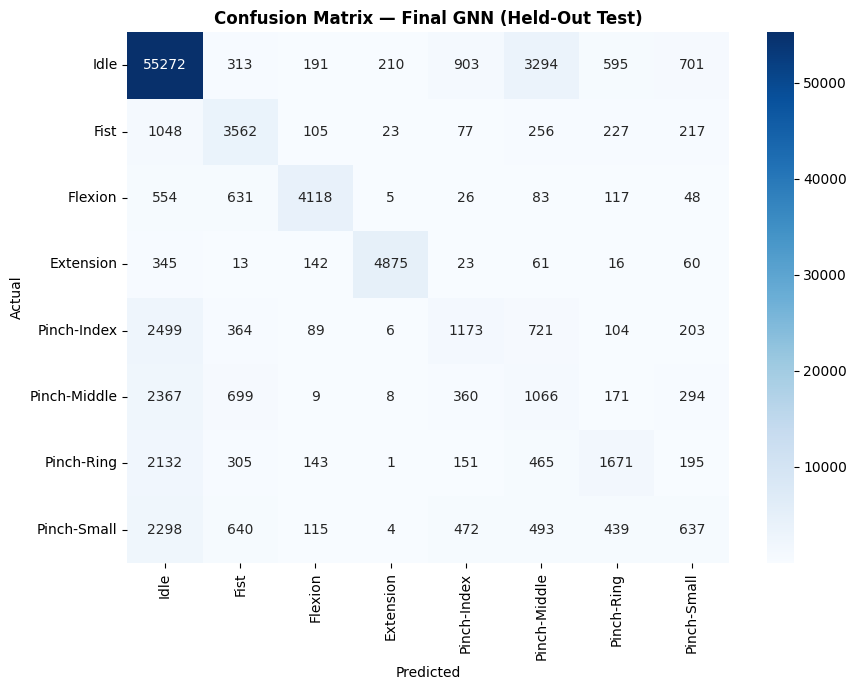

No further hyperparameter/model-selection changes should be made after this cell.


In [24]:
final_gnn_test_metrics, gnn_y_true, gnn_y_pred, gnn_y_proba = evaluate_gnn_dataframe(
    final_gnn_model,
    test_df,
    final_gnn_artifacts,
    batch_size=final_config.get("batch_size", 512),
)

baseline_test_metrics, baseline_y_true, baseline_y_pred, baseline_y_proba = (
    evaluate_task2_baseline_dataframe(
        final_baseline_model,
        test_df,
        final_baseline_artifacts,
    )
)

assert np.array_equal(gnn_y_true, baseline_y_true)

heldout_test_df = pd.DataFrame([
    {"Model": "Final GNN", **final_gnn_test_metrics},
    {"Model": best_baseline_name, **baseline_test_metrics},
]).sort_values("Macro-F1", ascending=False).reset_index(drop=True)

print("Held-out test results (same 7 subjects):")
display(heldout_test_df)
heldout_test_df.to_csv(
    OUTPUT_FOLDER / "heldout_test_comparison.csv",
    index=False,
)

class_names_final = [
    GESTURE_NAMES[int(c)]
    for c in final_gnn_artifacts["le"].classes_
]

print("\nFinal GNN classification report:")
print(
    classification_report(
        gnn_y_true,
        gnn_y_pred,
        target_names=class_names_final,
        zero_division=0,
    )
)

cm = confusion_matrix(gnn_y_true, gnn_y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_final,
    yticklabels=class_names_final,
    ax=ax,
)
ax.set_title(
    "Confusion Matrix — Final GNN (Held-Out Test)",
    fontweight="bold",
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print("No further hyperparameter/model-selection changes should be made after this cell.")


## Section 19 — Fair Project Comparison and Related-Work 




In [25]:
print("Controlled same-fold comparison:")
display(cv_summary_df)

print("\nFinal same-test-subject comparison:")
display(heldout_test_df)

historical_task2_df = pd.DataFrame([
    {
        "Model": best_baseline_name,
        "Task-2 validation Macro-F1": best_baseline_f1,
        "Purpose": "Historical Task-2 baseline result",
    },
    {
        "Model": "First Task-2 Corr-GCN",
        "Task-2 validation Macro-F1": first_gnn_f1,
        "Purpose": "Historical Task-2 first-GNN result",
    },
])
print("\nHistorical Task-2 fixed-validation results (context only):")
display(historical_task2_df)
historical_task2_df.to_csv(OUTPUT_FOLDER / "task2_historical_context.csv", index=False)


Controlled same-fold comparison:


,Model,Macro-F1 mean,Macro-F1 std,Accuracy mean,Balanced Accuracy mean,ROC-AUC mean,PR-AUC mean
0,MLP (PyTorch),0.533996,0.042183,0.655761,0.581452,0.865858,0.589146
1,Final GNN,0.514332,0.032502,0.724337,0.504680,0.858999,0.541317
2,First Task-2 Corr-GCN,0.403575,0.040675,0.610859,0.423309,0.802590,0.408156



Final same-test-subject comparison:


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted-F1,ROC-AUC,PR-AUC
0,MLP (PyTorch),0.604014,0.618944,0.519746,0.618944,0.541998,0.647337,0.877386,0.616836
1,Final GNN,0.735471,0.507510,0.558701,0.507510,0.523843,0.722166,0.857276,0.536259



Historical Task-2 fixed-validation results (context only):


,Model,Task-2 validation Macro-F1,Purpose
0,MLP (PyTorch),0.5346,Historical Task-2 baseline result
1,First Task-2 Corr-GCN,0.3821,Historical Task-2 first-GNN result


## Section 20 —  final model, exact preprocessing, graph, predictions, and Task-3 summary




In [26]:
import joblib

final_graph = final_gnn_artifacts["graph"]

# Save CPU checkpoint state plus graph/config metadata.
torch.save({
    "model_state": final_gnn_artifacts["best_state"],
    "config": final_config,
    "edge_index": final_graph["edge_index"].cpu(),
    "edge_weight": final_graph["edge_weight"].cpu(),
    "adjacency": final_graph["adj"],
    "correlation_matrix": final_graph["corr"],
    "feat_cols": feat_cols_7,
    "n_channels": N_CHANNELS,
    "n_metrics": N_METRICS,
    "label_classes": [int(c) for c in final_gnn_artifacts["le"].classes_],
    "validation_metrics": final_val_metrics,
    "test_metrics": final_gnn_test_metrics,
}, MODELS_FOLDER / "final_gnn_model.pth")

joblib.dump({
    "variance_threshold": final_gnn_artifacts["vt"],
    "robust_scaler": final_gnn_artifacts["scaler"],
    "label_encoder": final_gnn_artifacts["le"],
    "feat_cols": feat_cols_7,
}, MODELS_FOLDER / "final_gnn_preprocessing.joblib")

# Save row-aligned predictions so explainability can select one correct and one wrong sample.
original_true_labels = final_gnn_artifacts["le"].inverse_transform(gnn_y_true)
original_pred_labels = final_gnn_artifacts["le"].inverse_transform(gnn_y_pred)
prediction_records = {
    "row_index_in_test_df": np.arange(len(test_df)),
    "subject_id": test_df["subject_id"].to_numpy(),
    "true_label": original_true_labels,
    "pred_label": original_pred_labels,
    "correct": original_true_labels == original_pred_labels,
}
for col in ["window_id", "recording_id", "segment_id", "window_start", "window_end"]:
    if col in test_df.columns:
        prediction_records[col] = test_df[col].to_numpy()

predictions_df = pd.DataFrame(prediction_records)
for i, label_value in enumerate(final_gnn_artifacts["le"].classes_):
    predictions_df[f"proba_{GESTURE_NAMES[int(label_value)]}"] = gnn_y_proba[:, i]
predictions_df.to_csv(OUTPUT_FOLDER / "final_gnn_test_predictions.csv", index=False)

summary = {
    "final_config": final_config,
    "ablation_screening_rows": ablation_screen_df.to_dict("records"),
    "cv_summary": cv_summary_df.to_dict("records"),
    "wilcoxon": wilcoxon_result,
    "heldout_test_comparison": heldout_test_df.to_dict("records"),
    "best_task2_baseline": {
        "model": best_baseline_name,
        "validation_macro_f1": best_baseline_f1,
    },
    "first_task2_gnn_validation_macro_f1": first_gnn_f1,
}
with open(OUTPUT_FOLDER / "task3_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))

print("Saved -> models/final_gnn_model.pth")
print("Saved -> models/final_gnn_preprocessing.joblib")
print("Saved -> task3_results/final_gnn_test_predictions.csv")
print("Saved -> task3_results/task3_summary.json")
print("\nTask 3 improvement/ablation notebook complete.")
print("Next notebook: SHAP + LIME for one correct and one wrong final-GNN test sample.")


Saved -> models/final_gnn_model.pth
Saved -> models/final_gnn_preprocessing.joblib
Saved -> task3_results/final_gnn_test_predictions.csv
Saved -> task3_results/task3_summary.json

Task 3 improvement/ablation notebook complete.
Next notebook: SHAP + LIME for one correct and one wrong final-GNN test sample.
